# OVERVIEW
This notebook serves as examples and analysis of how to use the accompanying src .py files

In [ ]:
import sys
sys.path.append('../src')

#start by importing all things we need for the notebook

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing, make_classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.calibration import CalibratedClassifierCV
from models import prepare_data, evaluate_regression, polynomial_complexity_sweep, compare_models, evaluate_classifier, feature_importance
from plotting import plot_complexity_sweep
from validation import cv_complexity_sweep, cross_validate_model, tune_and_evaluate, threshold_sweep, calibration_check, regularisation_sweep


import warnings
warnings.filterwarnings('ignore')
np.seterr(all='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
data = fetch_california_housing()
X, y = data.data, data.target

print(f"Features: {data.feature_names}")

X_train, X_test, y_train, y_test, scaler = prepare_data(X, y)

model, results = evaluate_regression(LinearRegression(), X_train, X_test, y_train, y_test)
print(pd.Series(results))

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
model         LinearRegression
train_r2              0.609346
test_r2                0.59577
train_rmse            0.723435
test_rmse             0.728401
r2_gap                0.013576
dtype: object


In [3]:
sweep = polynomial_complexity_sweep(X, y, max_degree=5)
print(sweep)

        n_features  train_r2       test_r2           gap
degree                                                  
1                8    0.6093  5.958000e-01  1.360000e-02
2               44    0.6838  6.534000e-01  3.040000e-02
3              164    0.7436 -1.371640e+01  1.446010e+01
4              494    0.7897 -1.052243e+04  1.052322e+04
5             1286    0.8277 -2.578118e+07  2.578118e+07


If $R^2 < 0 $ that tells us the approximation is beaten by a constant. This puts into perspective how bad the test approximation is compared to the training. This is the divergencew in action. We do notice that the approximation does remain pretty accurate for degree 2 polynomials, but any greater and the models diverge wildly. This is due to the model overfitting to the training data, as seen by the number of features. This is the danger we encounter with ML in finance, the training data being past data, as evidenced in many previous projects. We can see this divergence better on this plot:

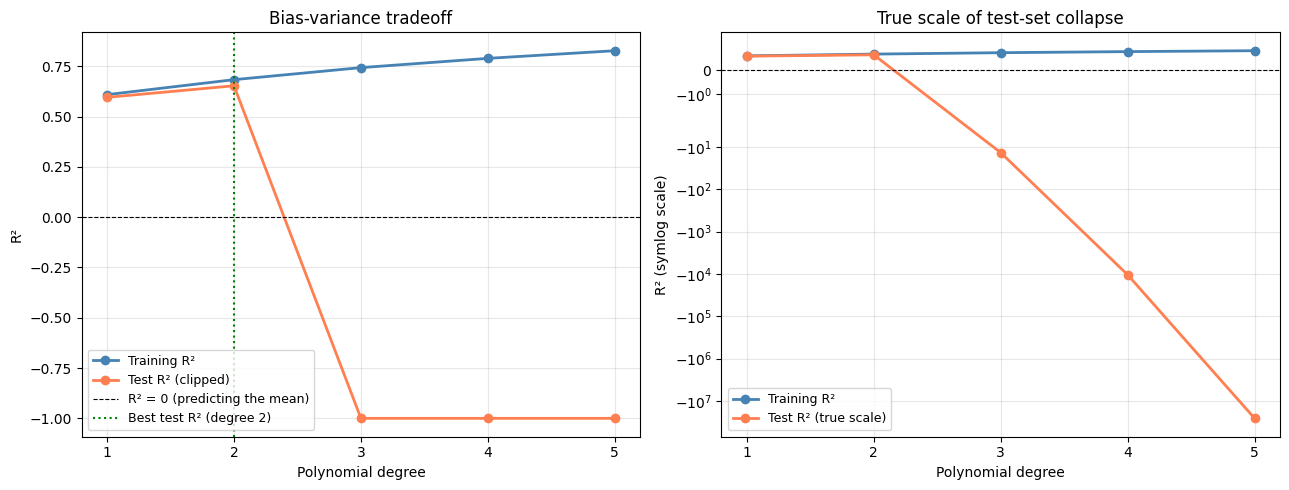

In [4]:
plot_complexity_sweep(sweep)

This shows how the divergence between the two models worsens over the increase of degree. One key thing to note is that this is only tested on one split of the data. We now look at cross-validation, i.e splitting the data up into k folds ($k \in \mathbb{N}$), training the data on k-1 folds and reserving the last for testing. Then we rotate which fold is reserved for testing until we have exhausted all of them. These sets of data tell us that the California housing market certainly does not follow a polynomial order greater than 2.

In [5]:
cv_sweep = cv_complexity_sweep(X, y, max_degree=4, k=5)
print(cv_sweep)

print("\nLinear regression, individual fold scores:")
cv = cross_validate_model(LinearRegression(), X, y, k=5)
print(np.round(cv['scores'], 4))
print(f"Mean: {cv['mean']:.4f}, Std: {cv['std']:.4f}")

          cv_mean_r2        cv_std    worst_fold  best_fold
degree                                                     
1       6.014000e-01  1.700000e-02  5.758000e-01     0.6213
2      -7.466790e+01  1.506446e+02 -3.759572e+02     0.6753
3      -7.959967e+05  1.591366e+06 -3.978729e+06     0.4147
4      -5.573189e+11  1.114634e+12 -2.786588e+12  -149.0356

Linear regression, individual fold scores:
[0.5758 0.6137 0.6086 0.6213 0.5875]
Mean: 0.6014, Std: 0.0170


Here we see the true value of this comparison. The quality of the model depends massively upon the set of training data. Notice that the r2 cv_means for all polynomials of degree > 1 are negative, meaning they are outperformed by constants, telling us the model is massively out in its estimations. This proves the above statement about degree 2 polynomials incorrect, it is just we choose a good set of training data. This tells us that the California housing market does not infact follow a polynomial of order 2, and doesn't fit to an order 1 (affine linear) polynomial particularly well. We see some level of stability with the linear regression model, with small standard deviation and similar quality each time. The quality of the approximation is not great per say, but it is independent of the split chosen. This leads us to seek alternative models.

In [6]:
comparison = compare_models(X, y, k=5)
print(comparison)

                   CV mean R²  CV std  Worst fold
Model                                            
Linear regression      0.6014  0.0170      0.5758
Ridge (alpha=1)        0.6014  0.0170      0.5758
Lasso (alpha=0.1)      0.4934  0.0104      0.4814
Decision tree          0.6138  0.0061      0.6051
Random forest          0.8097  0.0069      0.8042
Gradient boosting      0.7877  0.0110      0.7756


We see that the best performing model here is the Random forest, a model which forests many trees (each on a random subset of rows/features) and averages them, cancelling outliers. This led to the best approximation of the California housing market, with stability across splitting the dataset, leading us to believe that there is a nonlinear relationship (prices don't depend on latitude or houseage etc.). Another well performing model was Gradient boosting, a model which trains trees sequentially, fitting residual errors of the previous one. This can lead to a model which overfits to training data if not tuned. The worst performing model was the Lasso model, which is a regularised linear regression model that penalises absolute values, driving some to zero, effectively selecting important parameters.

In [ ]:
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.1)).fit(X, y)
coefs = lasso.named_steps['lasso'].coef_
print(pd.Series(coefs.round(4), index=data.feature_names))

MedInc        0.7057
HouseAge      0.1060
AveRooms     -0.0000
AveBedrms    -0.0000
Population   -0.0000
AveOccup     -0.0000
Latitude     -0.0112
Longitude    -0.0000
dtype: float64


Here we see from the Lasso model that features like latitude, longitude (location) are being eliminated, when we would expect them to contribute to the price of a house. 

We now discuss parameter tuning, where given a set of parameters, and a model, we choose the parameters which closest match this data. We have to be careful here with leaking. If we naively try enough parameter combinations on any split and take a maximum, then we've used every part of the data to make a decision. Then when we use the testing set, we have already leaked some data as we know (if enough parameters tested) there wasn't the maximum relationship achieved with these parameters. We do this, alongside a test which does the same thing, but deliberately holds a test dataset when training parameters and compare to see the bias.

We choose to test on the best performing model as evidenced above.

In [ ]:

param_grid = {'n_estimators': [50, 100], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 5, 20]}

best_rf, tuning_results = tune_and_evaluate(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid, X, y, test_size=0.2, k=3)

print("\nTop 5 configurations:")
print(tuning_results.head())

Best params:      {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV score:    0.8010
Holdout score:    0.8049
Optimism:         -0.0038

Top 5 configurations:
                                               params  mean_test_score  \
13  {'max_depth': None, 'min_samples_leaf': 1, 'n_...         0.801018   
7   {'max_depth': 20, 'min_samples_leaf': 1, 'n_es...         0.800261   
12  {'max_depth': None, 'min_samples_leaf': 1, 'n_...         0.797902   
15  {'max_depth': None, 'min_samples_leaf': 5, 'n_...         0.796976   
9   {'max_depth': 20, 'min_samples_leaf': 5, 'n_es...         0.796961   

    std_test_score  rank_test_score  
13        0.006702                1  
7         0.006771                2  
12        0.007326                3  
15        0.006903                4  
9         0.006928                5  


We see immediately that there is no 'optimism' (the first system above of testing with the parameters on testing data set and a maximum relationship not being achieved) bias from this model. This is primarily for one reason, when we look at the mean test scores of these 'optimal' parameters, they all sit within one standard deviation of each other (as calculated when discussing various models above). When each option performs near enough identically, "picking the maximum" doesn't cherry pick an outlier. If we had genuinely varying performances between parameters, then this would become an issue very quickly.

In [9]:
from sklearn.ensemble import RandomForestClassifier

There are some very important metrics we use here:
- Accuracy: fraction correct, i.e, is the stock up or down. Beware: model predicting 'up' every day can be correct 60% of the time and still predict nonsense.
- Precision: Of cases predicted positive, how many were actually positive?
- Recall: Of actual positives, how many did we predict?
- F1: Harmonic mean of precision, recall
- ROC_AUC: Probability that a randomly chose positive is ranked above a randomly chosen negative. Also is threshold independent, it measures whether the model ranks correctly regardless of the buy/sell cutoff


We use some testing to see which of these metrics is most useful.

In [15]:
X_c, y_c = make_classification(n_samples=5000, n_features=15, n_informative=8, weights=[0.9, 0.1], random_state=42)

print(f"Class balance: {np.bincount(y_c)}  ({y_c.mean()*100:.1f}% positive)\n")

Xc_train, Xc_test, yc_train, yc_test, _ = prepare_data(X_c, y_c)

rows = []
for name, clf in [
    ('Always predict majority', DummyClassifier(strategy='most_frequent')),
    ('Logistic regression', LogisticRegression(max_iter=1000)),
    ('Random forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),]:
    _, res = evaluate_classifier(clf, Xc_train, Xc_test, yc_train, yc_test, label=name)
    rows.append(res)

print(pd.DataFrame(rows).set_index('model'))

Class balance: [4481  519]  (10.4% positive)

                         accuracy  precision  recall      f1  roc_auc
model                                                                
Always predict majority    0.8940     0.0000  0.0000  0.0000   0.5000
Logistic regression        0.9340     0.9167  0.4151  0.5714   0.7951
Random forest              0.9527     0.9889  0.5597  0.7149   0.9598


We see that the class balance is very similar to the weight given. We see that the accuracy of the dummy classifier is ~90% even though its effectively a coinfilp, meaning accuracy alone is not a great metric. The metric which really seperates these is ROC_AUC, with random forest correctly rating a randomly chosen positive over a randomly chosen negative 96% of the time. In the trading world, mistakes are costly and so is missing opportunities. To counteract this we can lower the default threshold, trading precision for recall. In this case, ROC_AUC really matters, as the statistic is independent of the threshold chosen, so is unaffected by this change above. However, it is not perfect as we will see.

We now test the calibration of the model. If a calibrated model is 70% confident, it should be correct approximately 70% of the time.

In [11]:
rf, _ = evaluate_classifier(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), Xc_train, Xc_test, yc_train, yc_test)

print("Threshold sweep:")
print(threshold_sweep(rf, Xc_test, yc_test))

print("\nBefore Calibration:")
print(calibration_check(rf, Xc_test, yc_test))

Threshold sweep:
           n_signals  precision  recall      f1
threshold                                      
0.10             367     0.4060  0.9371  0.5665
0.15             213     0.6573  0.8805  0.7527
0.20             170     0.7882  0.8428  0.8146
0.25             149     0.8725  0.8176  0.8442
0.30             134     0.8806  0.7421  0.8055
0.35             119     0.9412  0.7044  0.8058
0.40             108     0.9352  0.6352  0.7566
0.45              99     0.9596  0.5975  0.7364
0.50              90     0.9889  0.5597  0.7149
0.55              83     0.9880  0.5157  0.6777
0.60              76     1.0000  0.4780  0.6468
0.65              65     1.0000  0.4088  0.5804
0.70              50     1.0000  0.3145  0.4785
0.75              38     1.0000  0.2390  0.3858
0.80              29     1.0000  0.1824  0.3085
0.85              21     1.0000  0.1321  0.2333
0.90               6     1.0000  0.0377  0.0727

Before Calibration:
   predicted_prob  actual_freq   error
0          

We see in the thresholds, as we increase the threshold, we decrease n_signals and recall, while increasing precision which makes sense as per their definitions. F1 increases until ~0.25, before decreasing, meaning that the most accurate way of predicting the most positives whilst predicting them accurately is to use a threshold ~0.25. Recall from above, we have ROC-AUC of around 0.96, so 96% of the time it is ranking positives above negatives, but we see that pre-calibration, there's a big error margin between the predicted probabilities and the actual frequencies. So it is accurate at ranking, but the confidence is significantly out compared to reality. If this was in finance, you would tend to invest proportionally to confidence, so here we would be leaving money on the table, since our machine is 59% confident that the cases are positive, but they are infact correct 87% of the time. We seek to improve this by calibrating.

In [ ]:

calibrated = CalibratedClassifierCV(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), method='isotonic', cv=3)
calibrated.fit(Xc_train, yc_train)

print("After calibration:")
print(calibration_check(calibrated, Xc_test, yc_test))
print(f"\nROC-AUC before: {roc_auc_score(yc_test, rf.predict_proba(Xc_test)[:,1]):.4f}")
print(f"ROC-AUC after:  {roc_auc_score(yc_test, calibrated.predict_proba(Xc_test)[:,1]):.4f}")

After calibration:
   predicted_prob  actual_freq   error
0          0.0024       0.0000 -0.0024
1          0.0058       0.0000 -0.0058
2          0.0079       0.0204  0.0125
3          0.0100       0.0147  0.0047
4          0.0118       0.0106 -0.0012
5          0.0167       0.0049 -0.0118
6          0.0218       0.0122 -0.0096
7          0.0370       0.0423  0.0053
8          0.1253       0.1333  0.0080
9          0.8180       0.8322  0.0142

ROC-AUC before: 0.9598
ROC-AUC after:  0.9535


We see the ROC-AUC before and after are effectively the same, so the machine is still just as good at ranking positives above negatives, but the confidence much closer matches the actual frequency now. The errors effectively vanish, so in the context of above, we can invest relative to the machine's confidence level and be comfortable it is accurate (if the data was stock market data). This reduces some of the opportunity lost, as we can better predict how much to buy/sell.

We now look at which features are important to the data. This is done by simulating without the feature and seeing how much performance drops. This process is called permutation importance, and is preferred to a model's built in importances as they are biased by training data.

In [13]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
X_train, X_test, y_train, y_test, _ = prepare_data(X, y, scale=False)

rf_reg.fit(X_train, y_train)

imp = feature_importance(rf_reg, X_test, y_test, data.feature_names)
print(imp)

            importance     std
feature                       
MedInc          0.7890  0.0142
Latitude        0.4192  0.0111
Longitude       0.3063  0.0067
AveOccup        0.2021  0.0074
HouseAge        0.0701  0.0027
AveRooms        0.0244  0.0012
AveBedrms       0.0098  0.0006
Population      0.0079  0.0008


We see in the California housing market that the most important features are the Median Income (how much a family can afford) and the latitude/longitude (location), which makes sense intuitively.

We end with a brief discussion about regularisation of Linear Regression. We saw earlier that Lasso ($\alpha = 0.1$) overshot, and Ridge ($\alpha = 1$) do nothing, with neither tuned.

In [14]:
reg_sweep = regularisation_sweep(X, y, k=3)
print(reg_sweep.to_string())

print(f"\nBest Ridge alpha: {reg_sweep['ridge_r2'].idxmax()} " f"(R² = {reg_sweep['ridge_r2'].max():.4f})")
print(f"Best Lasso alpha: {reg_sweep['lasso_r2'].idxmax()} " f"(R² = {reg_sweep['lasso_r2'].max():.4f})")

            ridge_r2  lasso_r2  lasso_features_kept
alpha                                              
0.00010       0.6035    0.6036                    8
0.00023       0.6035    0.6036                    8
0.00055       0.6035    0.6036                    8
0.00127       0.6035    0.6037                    8
0.00298       0.6035    0.6036                    8
0.00695       0.6035    0.6025                    7
0.01624       0.6035    0.5946                    7
0.03793       0.6035    0.5653                    5
0.08859       0.6035    0.4986                    3
0.20691       0.6035    0.4412                    1
0.48329       0.6035    0.2980                    1
1.12884       0.6035   -0.0001                    0
2.63665       0.6035   -0.0001                    0
6.15848       0.6036   -0.0001                    0
14.38450      0.6036   -0.0001                    0
33.59818      0.6036   -0.0001                    0
78.47600      0.6033   -0.0001                    0
183.29807   

We see as $\alpha$ increases, Lasso $ R^2 $ decreases and at the same we lose the number of lasso features kept. We also see that Ridge shrinks coefficients, but never eliminates them entirely, and even takes many many orders of magnitude to start degrade them. The main thing is the difference in the reaction to the same strength regularisation, with Ridge responding only slightly, and Lasso completely eliminating features, despite the strength of the regularisation being the same. 